# K-Means Feature Space Analysis: SST vs Chlorophyll-a vs SSL

This notebook builds a standardized (z-scored) feature space from SST, Chlorophyll-a, SSL, and month, runs K-means clustering, and applies the trained model to a June mean-state cluster map.

In [56]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

## Load the Pickle Dataset

In [57]:
# Load the pickle file
with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdom_ssl_2005-2019_v2.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

print(f"Dataset loaded successfully!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData availability:")
print(f"  SST: {df['sst'].notna().sum()} days")
print(f"  Chlorophyll: {df['chlorophyll'].notna().sum()} days")
print(f"  SSL: {df['ssl'].notna().sum()} days")

Dataset loaded successfully!
Date range: 2010-01-01 00:00:00 to 2020-01-01 00:00:00
Total records: 3662
Columns: ['sst', 'sst_n_points', 'chlorophyll', 'chlor_n_points', 'cdom', 'ssl', 'ssl_n_points']

Data availability:
  SST: 3662 days
  Chlorophyll: 3651 days
  SSL: 3652 days


## Extract and Flatten Data for Clustering

In [58]:
# Extract all data points from the gridded dataset
sst_values = []
chlor_values = []
ssl_values = []
month_values = []

for date_idx, row in df.iterrows():
    month = date_idx.month

    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    ssl_grid = row['ssl']

    if sst_grid is None or chlor_grid is None or ssl_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
        continue

    sst_array = np.array(sst_grid)
    chlor_array = np.array(chlor_grid)
    ssl_array = np.array(ssl_grid)

    ssl_nan_mask = np.isnan(ssl_array)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_array.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_array)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_array = ssl_blurred

    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    ssl_flat = ssl_array.flatten()

    valid_mask = ~np.isnan(sst_flat) & ~np.isnan(chlor_flat) & ~np.isnan(ssl_flat) & (chlor_flat > 0)

    sst_values.extend(sst_flat[valid_mask])
    chlor_values.extend(chlor_flat[valid_mask])
    ssl_values.extend(ssl_flat[valid_mask])
    month_values.extend([month] * np.sum(valid_mask))

sst_values = np.array(sst_values)
chlor_values = np.array(chlor_values)
ssl_values = np.array(ssl_values)
month_values = np.array(month_values)

print(f"Total valid data points before subsampling: {len(sst_values):,}")

max_points = 5000
if len(sst_values) > max_points:
    np.random.seed(42)
    random_indices = np.random.choice(len(sst_values), size=max_points, replace=False)
    sst_values = sst_values[random_indices]
    chlor_values = chlor_values[random_indices]
    ssl_values = ssl_values[random_indices]
    month_values = month_values[random_indices]
    print(f"Subsampled to {max_points:,} points")
else:
    print(f"Using all {len(sst_values):,} points (less than {max_points:,})")

print(f"Months represented: {sorted(np.unique(month_values))}")
print(f"SST range: {np.min(sst_values):.2f} to {np.max(sst_values):.2f} °C")
print(f"Chlorophyll range: {np.min(chlor_values):.4f} to {np.max(chlor_values):.4f} mg/m³")
print(f"SSL range: {np.min(ssl_values):.4f} to {np.max(ssl_values):.4f} m")

Total valid data points before subsampling: 60,419,911
Subsampled to 5,000 points
Months represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
SST range: 21.10 to 31.10 °C
Chlorophyll range: 0.0318 to 60.0630 mg/m³
SSL range: -0.0224 to 1.0623 m


In [59]:
# Prepare feature matrix: [log10(Chlor), SST, SSL, Month]
chlor_log = np.log10(chlor_values)

features = np.column_stack([
    chlor_log,
    sst_values,
    ssl_values,
    month_values
])

print(f"Feature matrix shape: {features.shape}")
print("Features: [log10(Chlor), SST, SSL, Month]")

# Z-score standardization before K-means
scaler = StandardScaler()
features_z = scaler.fit_transform(features)

print("\nZ-score scaling applied before K-means (mean≈0, std≈1)")
print(f"Scaled means: {np.round(features_z.mean(axis=0), 3)}")
print(f"Scaled stds : {np.round(features_z.std(axis=0), 3)}")

# Apply K-means on z-scored data
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_z)

print(f"\nK-means clustering with {n_clusters} clusters:")
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    pct = 100 * count / len(cluster_labels)
    print(f"  Cluster {i}: {count:,} points ({pct:.1f}%)")

# Cluster centers mapped back to original feature scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster centers (original scale):")
feature_names = ['log10(Chlor)', 'SST', 'SSL', 'Month']
for i in range(n_clusters):
    print(f"\n  Cluster {i}:")
    for j, name in enumerate(feature_names):
        print(f"    {name}: {cluster_centers_original[i, j]:.3f}")

# Compute PCA from z-scored feature matrix for visualization
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_z)
print(
    f"\nPCA computed — variance explained: "
    f"PC1={100*pca.explained_variance_ratio_[0]:.1f}%, "
    f"PC2={100*pca.explained_variance_ratio_[1]:.1f}% "
    f"(total={100*pca.explained_variance_ratio_.sum():.1f}%)"
 )

Feature matrix shape: (5000, 4)
Features: [log10(Chlor), SST, SSL, Month]

Z-score scaling applied before K-means (mean≈0, std≈1)
Scaled means: [-0. -0.  0. -0.]
Scaled stds : [1. 1. 1. 1.]

K-means clustering with 4 clusters:
  Cluster 0: 717 points (14.3%)
  Cluster 1: 1,076 points (21.5%)
  Cluster 2: 1,633 points (32.7%)
  Cluster 3: 1,574 points (31.5%)

Cluster centers (original scale):

  Cluster 0:
    log10(Chlor): -1.121
    SST: 28.306
    SSL: 0.679
    Month: 6.601

  Cluster 1:
    log10(Chlor): -0.044
    SST: 26.718
    SSL: 0.340
    Month: 10.271

  Cluster 2:
    log10(Chlor): -0.495
    SST: 25.109
    SSL: 0.269
    Month: 2.773

  Cluster 3:
    log10(Chlor): -0.842
    SST: 28.684
    SSL: 0.327
    Month: 8.230

PCA computed — variance explained: PC1=47.5%, PC2=27.3% (total=74.7%)


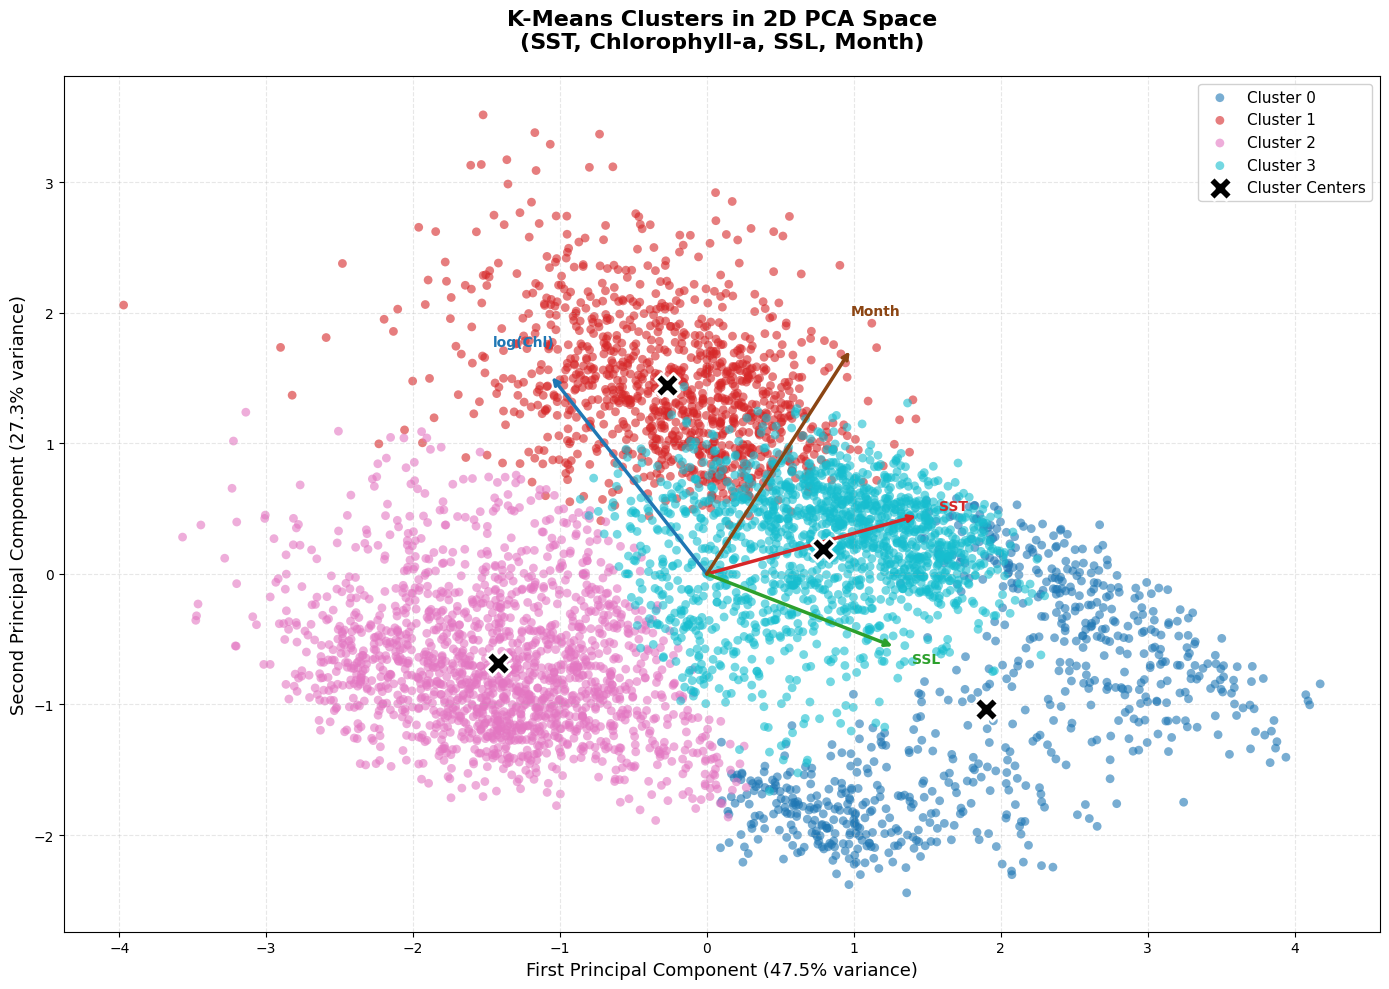


PCA visualization complete!
Total variance explained by 2 components: 74.7%


In [60]:
# Create 2D PCA visualization of clusters
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors for clusters
cmap = plt.get_cmap('tab10', n_clusters)
colors = [cmap(i) for i in range(n_clusters)]
cluster_names = [f'Cluster {i}' for i in range(n_clusters)]

# Plot each cluster
for i in range(n_clusters):
    mask = cluster_labels == i
    ax.scatter(
        features_pca[mask, 0],
        features_pca[mask, 1],
        c=[colors[i]],
        label=cluster_names[i],
        s=40,
        alpha=0.6,
        edgecolors='none'
    )

# Plot cluster centers in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='black',
    marker='X',
    s=300,
    edgecolors='white',
    linewidths=2,
    label='Cluster Centers',
    zorder=5
)

# Labels and title
ax.set_xlabel(f'First Principal Component ({100*pca.explained_variance_ratio_[0]:.1f}% variance)', 
              fontsize=13)
ax.set_ylabel(f'Second Principal Component ({100*pca.explained_variance_ratio_[1]:.1f}% variance)', 
              fontsize=13)
ax.set_title('K-Means Clusters in 2D PCA Space\n(SST, Chlorophyll-a, SSL, Month)', 
             fontsize=16, fontweight='bold', pad=20)

# --- PCA loading rays (biplot arrows) ---
# Scale arrows to ~40% of the smaller axis range so they are clearly visible
x_range = features_pca[:, 0].max() - features_pca[:, 0].min()
y_range = features_pca[:, 1].max() - features_pca[:, 1].min()
arrow_scale = min(x_range, y_range) * 0.4

loading_feature_names = ['log(Chl)', 'SST', 'SSL', 'Month']
loading_colors = ['tab:blue', 'tab:red', 'tab:green', 'saddlebrown']

for j, (fname, fcolor) in enumerate(zip(loading_feature_names, loading_colors)):
    dx = pca.components_[0, j] * arrow_scale
    dy = pca.components_[1, j] * arrow_scale
    ax.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=fcolor, lw=2.5, shrinkA=0, shrinkB=0)
    )
    ax.text(dx * 1.18, dy * 1.18, fname, color=fcolor, fontsize=10,
            fontweight='bold', ha='center', va='center')

# Legend
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\nPCA visualization complete!")
print(f"Total variance explained by 2 components: {100*np.sum(pca.explained_variance_ratio_):.1f}%")


C:\Users\Makai\AppData\Local\Temp\ipykernel_35492\3456150881.py:42: RuntimeWarning: Mean of empty slice
  mean_sst = np.nanmean(np.stack(june_sst_grids, axis=0), axis=0)
C:\Users\Makai\AppData\Local\Temp\ipykernel_35492\3456150881.py:43: RuntimeWarning: Mean of empty slice
  mean_chlor = np.nanmean(np.stack(june_chlor_grids, axis=0), axis=0)


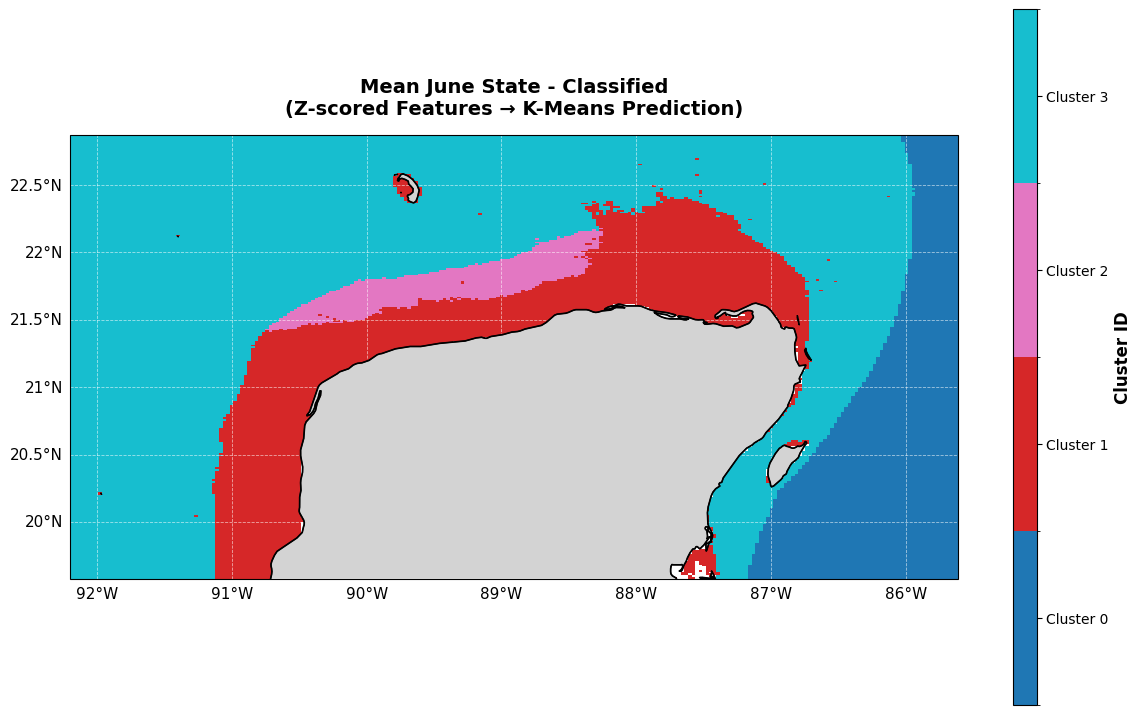

Mean June map generated!
Valid pixels classified: 45,035
June scenes averaged: 300


In [63]:
# Build June mean-state grids used for map classification
june_sst_grids = []
june_chlor_grids = []
june_ssl_grids = []

for date_idx, row in df.iterrows():
    if date_idx.month != 6:
        continue

    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    ssl_grid = row['ssl']

    if sst_grid is None or chlor_grid is None or ssl_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
        continue

    sst_arr = np.array(sst_grid, dtype=float)
    chlor_arr = np.array(chlor_grid, dtype=float)
    ssl_arr = np.array(ssl_grid, dtype=float)

    ssl_nan_mask = np.isnan(ssl_arr)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_arr.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_arr)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_arr = ssl_blurred

    june_sst_grids.append(sst_arr)
    june_chlor_grids.append(chlor_arr)
    june_ssl_grids.append(ssl_arr)

if len(june_sst_grids) == 0:
    raise ValueError('No valid June records found for map generation.')

mean_sst = np.nanmean(np.stack(june_sst_grids, axis=0), axis=0)
mean_chlor = np.nanmean(np.stack(june_chlor_grids, axis=0), axis=0)
mean_ssl = np.nanmean(np.stack(june_ssl_grids, axis=0), axis=0)

lon_centers = np.array(metadata['lon_centers'])
lat_centers = np.array(metadata['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

# Flatten the June mean grids for K-means prediction
mean_chlor_flat = mean_chlor.flatten()
mean_sst_flat = mean_sst.flatten()
mean_ssl_flat = mean_ssl.flatten()

valid_mask_mean = (
    ~np.isnan(mean_chlor_flat)
    & ~np.isnan(mean_sst_flat)
    & ~np.isnan(mean_ssl_flat)
    & (mean_chlor_flat > 0)
)

chlor_valid = mean_chlor_flat[valid_mask_mean]
sst_valid = mean_sst_flat[valid_mask_mean]
ssl_valid = mean_ssl_flat[valid_mask_mean]

# Match training feature format: [log10(Chlor), SST, SSL, Month]
mean_features = np.column_stack([
    np.log10(chlor_valid),
    sst_valid,
    ssl_valid,
    np.full_like(sst_valid, 6.0)
])

# Apply the same z-score transform and trained K-means model
mean_features_z = scaler.transform(mean_features)
mean_clusters = kmeans.predict(mean_features_z)

mean_cluster_grid = np.full(mean_chlor.shape, np.nan)
mean_cluster_grid.flat[valid_mask_mean] = mean_clusters

# Plot the smooth cluster map
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

cmap_base = plt.get_cmap('tab10', n_clusters)
colors = [cmap_base(i) for i in range(n_clusters)]
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

mesh = ax.pcolormesh(
    lon_grid_2d,
    lat_grid_2d,
    mean_cluster_grid,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading='auto',
    zorder=1
)

ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=4)

gl = ax.gridlines(draw_labels=True, linewidth=0.6, color='white', alpha=0.6, linestyle='--', zorder=2)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

cluster_names = [f'Cluster {i}' for i in range(n_clusters)]
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05, shrink=0.8, aspect=30)
cbar.set_label('Cluster ID', fontsize=12, weight='bold')
cbar.set_ticks(np.arange(0, n_clusters, 1))
cbar.ax.set_yticklabels(cluster_names, fontsize=10)

plt.title(
    'Mean June State - Classified\n(Z-scored Features → K-Means Prediction)',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

print('Mean June map generated!')
print(f'Valid pixels classified: {np.sum(valid_mask_mean):,}')
print(f'June scenes averaged: {len(june_sst_grids)}')